In [37]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

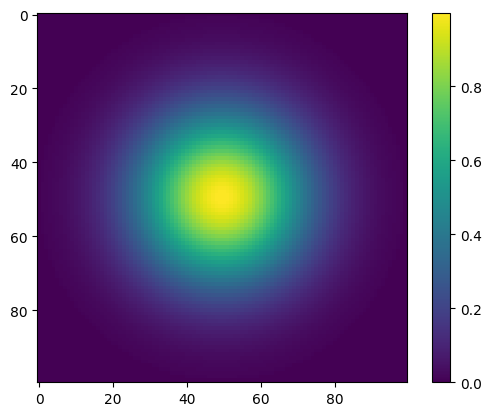

In [ ]:
#creating the aperture space

#Defined input variables
N = 100 #N value
aperture_radius = 250 #mm

#embedded grid for FFT
embedded_grid = 2048

#For beam mapping
lamda = 3.0 #mm
r_angle = 0

#further from axis (slope)
theta = 0  #direction
unknown_scalar = 1 #find from trial and error after completed code
k = 2 * np.pi / lamda 

#can change edge taper to .1 to get more gaussian (amplitude)
def create_aperture(N, aperture_radius, embedded_grid=None, edge_taper = 1.0):
    if embedded_grid is None:
        embedded_grid = N

    x = np.linspace(-aperture_radius,aperture_radius,N)
    y = np.linspace(-aperture_radius,aperture_radius,N)
    dx = x[1] - x[0] #pixel spacing in mm (helps to convert to unit of angle)

    x_grid,y_grid = np.meshgrid(x,y)
    aperture = np.zeros(shape=(N,N),dtype=complex)

    #Computes distance from origin to each grid point
    r = np.sqrt(x_grid**2 + y_grid**2)

    #calculate beam shape with desired edge taper (amplitude)
    alpha = -np.log(edge_taper)/aperture_radius**2
    #Creates circular aperture
    aperture[r < aperture_radius] = np.exp(-alpha*r[r < aperture_radius]**2)

    #dtheta/dx (x) dtheta/dy (y)
    phase_gradient = r_angle / aperture_radius * (np.cos(theta) * x_grid + np.sin(theta) * y_grid)
    aperture *= np.exp(1j * k* phase_gradient) 
    
    #embedding
    embedded = np.zeros((embedded_grid, embedded_grid), dtype=complex)

    #where to begin placing the aperture thats wrapped in zeros
    start = (embedded_grid - N) // 2
    embedded[start:start+N, start:start+N] = aperture


    return aperture, embedded, dx

aperture, embedded, dx = create_aperture(N, aperture_radius,embedded_grid, edge_taper=.01)
plt.imshow(np.abs(aperture))
plt.colorbar()

In [74]:
# #Near field projection 
# x_field = np.linspace(-1000,1000,100) #mm about 2m across
# y_field = np.linspace(-1000,1000,100)
# z = 10000

# x_grid_field , y_grid_field = np.meshgrid(x_field,y_field)

# def near_field_creation(aperture,x_grid, y_grid, x_field,y_field,z,k):
#     near_field = np.zeros((len(x_field), len(y_field)), dtype=complex)
#     #change to vectorized approach for faster speed at higher res for FFT?
#     for i in range(len(x_field)):
#         for j in range(len(y_field)):

#             #2d array of distances
#             d = np.sqrt((x_grid - x_field[i])**2 + (y_grid - y_field[j])**2 + z**2)
#             near_field[i,j] = np.sum(aperture * np.exp(1j *k * d) /d )

#     return near_field

# near_field = near_field_creation(aperture, x_grid_field, y_grid_field, x_field ,y_field,z,k)

# plt.imshow(np.log(np.abs(near_field)))
# plt.colorbar()


In [75]:
#saved data used to create graphs and data points for aperture and then near field
# np.savez("fourth_position.npz", near_field= near_field,aperture = aperture,x_grid =x_grid, y_grid = y_grid, x_field =x_field,y_field = y_field,z=z,k=k)

# #store different plots into variables
# first_pos = np.load("first_position.npz")

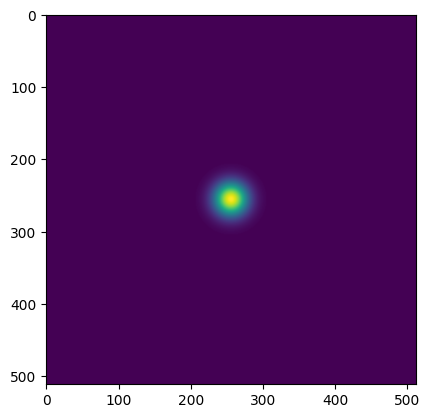

In [76]:
#(Fraunhofer diffraction integral) compute to far field with scaling factor
far_field = np.fft.fft2(embedded) * dx ** 2 

#shift to center
far_field_shifted = np.fft.fftshift(far_field)

#intensity?
viz_far_field = np.abs(far_field_shifted) **2
#normalizing the peak (1) and plotting the log so visible
viz_far_field = 10 * np.log10(viz_far_field / np.max(viz_far_field) + 1e-12)


#compute angular axes
fx = np.fft.fftshift(np.fft.fftfreq(embedded_grid, d=dx)) 
fy = np.fft.fftshift(np.fft.fftfreq(embedded_grid, d=dx))
FX, FY = np.meshgrid(fx,fy)
x_theta = lamda * FX
y_theta = lamda * FY

plt.imshow(np.abs(embedded))

In [77]:
print(lamda)
print(dx)

3.0
5.050505050505052


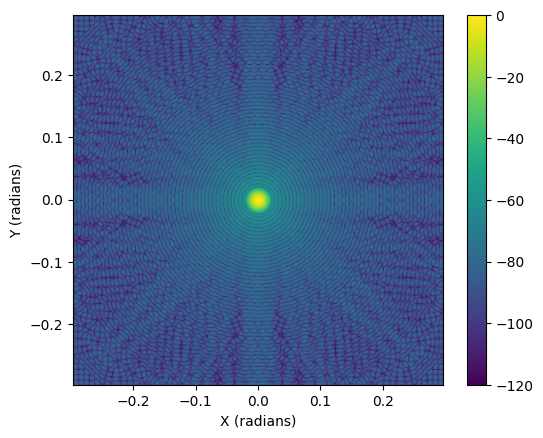

In [78]:
#plot in rad space [using angular axes]
plt.imshow(viz_far_field, extent=[x_theta.min(), x_theta.max(),y_theta.min(), y_theta.max()])
plt.xlabel("X (radians)")
plt.ylabel("Y (radians)")
plt.colorbar()


(-100.0, 0.0)

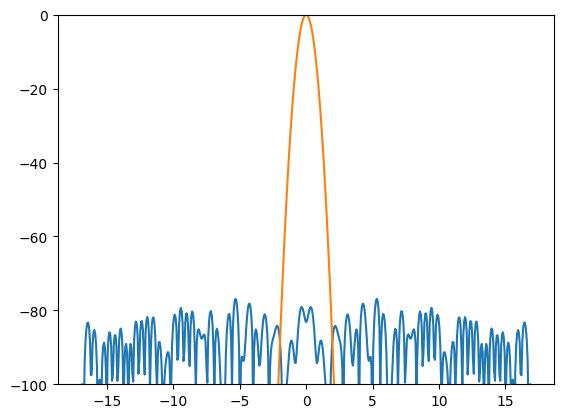

In [79]:
y_deg = y_theta[:,100] * 180 / np.pi
plt.plot(y_deg, viz_far_field[:,100])
plt.plot(y_deg, -y_deg**2 / (2 * (8.9/60)**2))
plt.ylim(-100, 0)